# 05 — ML Training

**Threat Incident Intelligence Platform**

This notebook trains classical ML models for:
1. **Urgency classification** — TF-IDF + Logistic Regression / Linear SVM
2. **Priority classification** — structured scores + text signals → Low/Medium/High/Critical

Artifacts are saved under `models/` so both later notebooks and Streamlit can load them.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai


In [2]:
import json
from datetime import datetime
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC

from src.config import settings, validate_config
from src.db import ping_database, close_connection, count_incidents, find_incidents
from src.preprocessing import clean_text, build_tfidf_corpus
from src.models.loaders import get_models_dir, load_joblib_model
from src.utils import setup_logging, timer, safe_float, safe_int

logger = setup_logging("INFO", name="ml_training")
validate_config()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

MODELS_DIR = get_models_dir()
RANDOM_STATE = 42
print(f"Models directory: {MODELS_DIR}")
print("Setup complete")

[config] MongoDB URI loaded (db=threat_intelligence)
[config] Collections: ['incidents', 'incident_features', 'predictions', 'models_metadata']
Models directory: C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models
Setup complete


In [3]:
if not ping_database():
    raise RuntimeError("Cannot reach MongoDB. Check .env and ensure the server is running.")

total = count_incidents()
print(f"Total incidents: {total:,}")
if total == 0:
    raise RuntimeError("No documents found. Run 01_data_ingestion.ipynb first.")

Total incidents: 19,204


In [4]:
with timer("Loading incidents"):
    docs = find_incidents(
        projection={
            "_id": 0,
            "cluster_id": 1,
            "title": 1,
            "summary": 1,
            "title_clean": 1,
            "summary_clean": 1,
            "keywords": 1,
            "urgency_level": 1,
            "threat_score": 1,
            "severity_score": 1,
            "credibility_score": 1,
            "source_count": 1,
            "article_count": 1,
        }
    )

df = pd.DataFrame(docs)
print(f"Shape: {df.shape}")
df.head(2)

[timer] Loading incidents: 0.40s
Shape: (19204, 12)


,cluster_id,title,title_clean,summary,summary_clean,keywords,source_count,article_count,threat_score,severity_score,credibility_score,urgency_level
0,971184ec,MikroTik RouterOS Vulnerabilities Under Active...,mikrotik routeros vulnerabilities under active...,CERT Polska has identified six critical vulner...,cert polska has identified six critical vulner...,"[mikrotik, routeros, vulnerability, vulnerabil...",2,2,78.65,85.0,0.0,medium
1,ec7534a8,Cyber Security Roles Address NHS Threats Amid ...,cyber security roles address nhs threats amid ...,Two cybersecurity roles have been announced to...,two cybersecurity roles have been announced to...,"[security, cyber, analyst, remote, consultant,...",2,2,39.00,40.0,0.0,medium


In [5]:
def combine_text(row: pd.Series) -> str:
    title = row.get("title_clean") or clean_text(str(row.get("title") or ""))
    summary = row.get("summary_clean") or clean_text(str(row.get("summary") or ""))
    keywords = row.get("keywords") or []
    kw = " ".join(str(k) for k in keywords if k)
    return " ".join(p for p in [title, summary, kw] if p)

with timer("Building text corpus"):
    df["text_combined"] = df.apply(combine_text, axis=1)

print(f"Empty texts: {(df['text_combined'].str.len() == 0).sum()}")

[timer] Building text corpus: 0.61s
Empty texts: 0


In [6]:
vectorizer_path = MODELS_DIR / "tfidf_vectorizer.joblib"

if vectorizer_path.exists():
    vectorizer = joblib.load(vectorizer_path)
    print(f"Loaded existing TF-IDF vectorizer from {vectorizer_path}")
    X_text = vectorizer.transform(df["text_combined"].tolist())
else:
    from sklearn.feature_extraction.text import TfidfVectorizer
    print("No saved vectorizer found — fitting a new one")
    corpus = build_tfidf_corpus(df["text_combined"].tolist())
    vectorizer = TfidfVectorizer(
        max_features=10_000, ngram_range=(1, 2), min_df=3, max_df=0.90, sublinear_tf=True
    )
    X_text = vectorizer.fit_transform(corpus)
    joblib.dump(vectorizer, vectorizer_path)
    print(f"Saved new vectorizer → {vectorizer_path}")

print(f"TF-IDF shape: {X_text.shape}")

Loaded existing TF-IDF vectorizer from C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\tfidf_vectorizer.joblib
TF-IDF shape: (19204, 10000)


In [7]:
df["urgency"] = df["urgency_level"].fillna("unknown").astype(str).str.strip().str.lower()
label_counts = df["urgency"].value_counts()
print("Raw urgency distribution:")
print(label_counts.to_string())

MIN_CLASS_COUNT = 20
valid_labels = label_counts[label_counts >= MIN_CLASS_COUNT].index.tolist()
mask = df["urgency"].isin(valid_labels)

df_u = df[mask].reset_index(drop=True)
X_u = X_text[mask.values]
y_u = df_u["urgency"].values

print(f"\nUsable samples: {len(df_u):,}  |  classes: {valid_labels}")
print(pd.Series(y_u).value_counts().to_string())

Raw urgency distribution:
urgency
medium      19127
low            68
info            4
high            3
critical        2

Usable samples: 19,195  |  classes: ['medium', 'low']
medium    19127
low          68


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_u, y_u, test_size=0.2, random_state=RANDOM_STATE, stratify=y_u
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Train: 15,356  |  Test: 3,839


In [9]:
def evaluate_classifier(name: str, model, X_te, y_te) -> Dict[str, Any]:
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_te, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro F1       : {f1_macro:.4f}")
    print(f"Weighted F1    : {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))

    cm = confusion_matrix(y_te, y_pred, labels=model.classes_)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_, ax=ax)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": name,
        "accuracy": float(acc),
        "macro_f1": float(f1_macro),
        "weighted_f1": float(f1_weighted),
        "classes": list(model.classes_),
    }

[timer] Training LogisticRegression: 10.19s

Logistic Regression (urgency)
Accuracy       : 0.9906
Macro F1       : 0.4976
Weighted F1    : 0.9917

Classification Report:
              precision    recall  f1-score   support

         low       0.00      0.00      0.00        14
      medium       1.00      0.99      1.00      3825

    accuracy                           0.99      3839
   macro avg       0.50      0.50      0.50      3839
weighted avg       0.99      0.99      0.99      3839



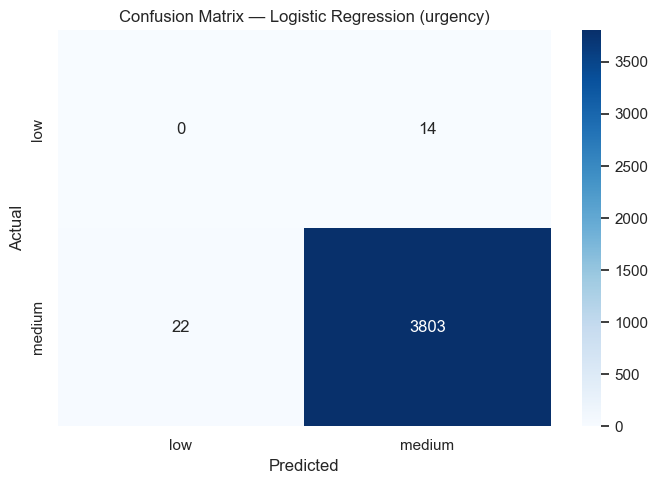

In [10]:
with timer("Training LogisticRegression"):
    lr = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    lr.fit(X_train, y_train)

lr_metrics = evaluate_classifier("Logistic Regression (urgency)", lr, X_test, y_test)

[timer] Training LinearSVC: 1.81s

Linear SVM (urgency)
Accuracy       : 0.9948
Macro F1       : 0.4987
Weighted F1    : 0.9938

Classification Report:
              precision    recall  f1-score   support

         low       0.00      0.00      0.00        14
      medium       1.00      1.00      1.00      3825

    accuracy                           0.99      3839
   macro avg       0.50      0.50      0.50      3839
weighted avg       0.99      0.99      0.99      3839



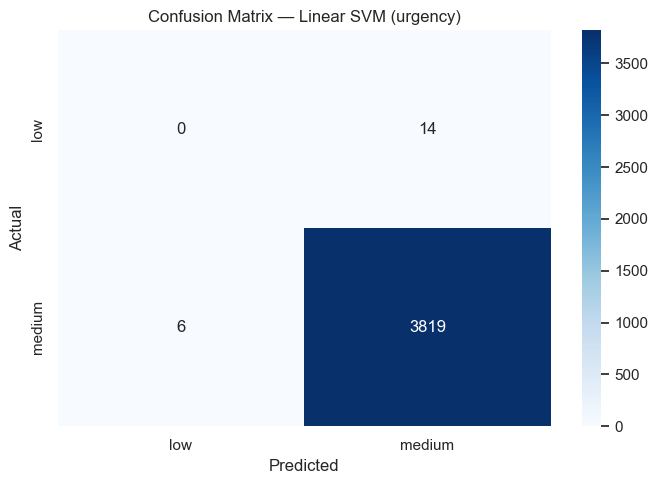

In [11]:
with timer("Training LinearSVC"):
    svm = LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=2000,
        dual="auto",
    )
    svm.fit(X_train, y_train)

svm_metrics = evaluate_classifier("Linear SVM (urgency)", svm, X_test, y_test)

In [12]:
if lr_metrics["macro_f1"] >= svm_metrics["macro_f1"]:
    best_urgency_model = lr
    best_urgency_name = "logistic_regression"
    best_urgency_metrics = lr_metrics
else:
    best_urgency_model = svm
    best_urgency_name = "linear_svm"
    best_urgency_metrics = svm_metrics

urgency_path = MODELS_DIR / "urgency_classifier.joblib"
joblib.dump(best_urgency_model, urgency_path)
print(f"Best urgency model: {best_urgency_name} (macro F1={best_urgency_metrics['macro_f1']:.4f})")
print(f"Saved → {urgency_path}")

Best urgency model: linear_svm (macro F1=0.4987)
Saved → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\urgency_classifier.joblib


In [13]:
def derive_priority(row: pd.Series) -> str:
    """Project-defined priority from scores + urgency."""
    threat = safe_float(row.get("threat_score"), default=0.0)
    severity = safe_float(row.get("severity_score"), default=0.0)
    urgency = str(row.get("urgency_level") or "").lower()

    if threat >= 80 or urgency in ("critical",) or (urgency == "high" and severity >= 70):
        return "critical"
    if threat >= 60 or urgency == "high":
        return "high"
    if threat >= 35 or urgency == "medium":
        return "medium"
    return "low"

df["priority"] = df.apply(derive_priority, axis=1)
print("Priority distribution:")
print(df["priority"].value_counts().to_string())

Priority distribution:
priority
medium      13914
high         5120
critical       98
low            72


In [14]:
struct_cols = ["threat_score", "severity_score", "credibility_score",
               "source_count", "article_count"]
struct_cols = [c for c in struct_cols if c in df.columns]

X_struct = df[struct_cols].apply(pd.to_numeric, errors="coerce").fillna(0).values
y_priority = df["priority"].values

print(f"Structured features: {struct_cols}")
print(f"X_struct shape: {X_struct.shape}")

Structured features: ['threat_score', 'severity_score', 'credibility_score', 'source_count', 'article_count']
X_struct shape: (19204, 5)


[timer] Training RandomForest (priority): 1.17s

Random Forest (priority)
Accuracy       : 0.9990
Macro F1       : 0.9665
Weighted F1    : 0.9990

Classification Report:
              precision    recall  f1-score   support

    critical       1.00      1.00      1.00        20
        high       1.00      1.00      1.00      1024
         low       0.81      0.93      0.87        14
      medium       1.00      1.00      1.00      2783

    accuracy                           1.00      3841
   macro avg       0.95      0.98      0.97      3841
weighted avg       1.00      1.00      1.00      3841



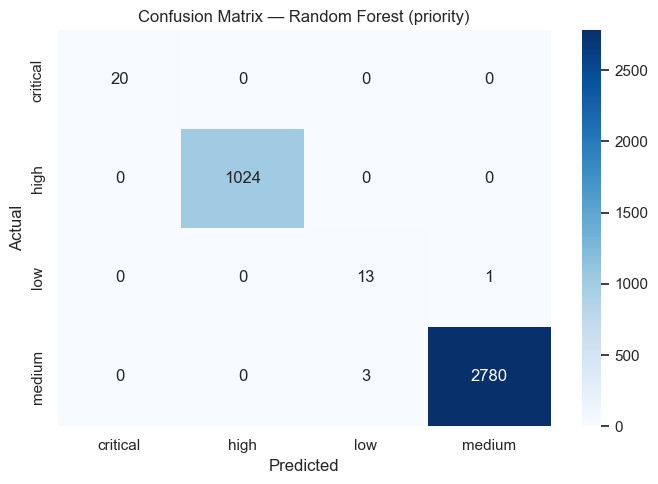

In [15]:
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_struct, y_priority, test_size=0.2, random_state=RANDOM_STATE, stratify=y_priority
)

with timer("Training RandomForest (priority)"):
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_tr_s, y_tr_s)

rf_metrics = evaluate_classifier("Random Forest (priority)", rf, X_te_s, y_te_s)

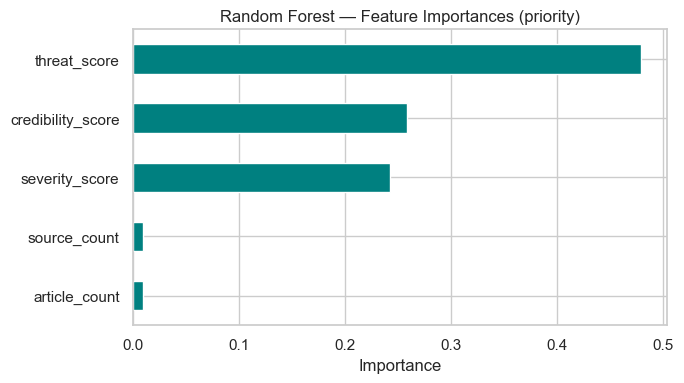

threat_score         0.479081
credibility_score    0.258624
severity_score       0.242504
source_count         0.010043
article_count        0.009748


In [16]:
imp = pd.Series(rf.feature_importances_, index=struct_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Random Forest — Feature Importances (priority)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False).to_string())

In [17]:
priority_path = MODELS_DIR / "priority_model.joblib"
joblib.dump(rf, priority_path)

priority_meta = {
    "feature_columns": struct_cols,
    "classes": list(rf.classes_),
}
joblib.dump(priority_meta, MODELS_DIR / "priority_meta.joblib")

print(f"Saved priority model → {priority_path}")
print(f"Saved priority meta  → {MODELS_DIR / 'priority_meta.joblib'}")

Saved priority model → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\priority_model.joblib
Saved priority meta  → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\priority_meta.joblib


In [18]:
metadata = {
    "trained_at": datetime.utcnow().isoformat() + "Z",
    "urgency_classifier": {
        "file": "urgency_classifier.joblib",
        "algorithm": best_urgency_name,
        "metrics": best_urgency_metrics,
        "features": "tfidf",
        "vectorizer": "tfidf_vectorizer.joblib",
    },
    "priority_model": {
        "file": "priority_model.joblib",
        "algorithm": "random_forest",
        "metrics": rf_metrics,
        "feature_columns": struct_cols,
    },
    "dataset_size": len(df),
    "random_state": RANDOM_STATE,
}

meta_path = MODELS_DIR / "metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved metadata → {meta_path}")
print(json.dumps(metadata, indent=2))

Saved metadata → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\metadata.json
{
  "trained_at": "2026-10-06T08:24:53.926258Z",
  "urgency_classifier": {
    "file": "urgency_classifier.joblib",
    "algorithm": "linear_svm",
    "metrics": {
      "model_name": "Linear SVM (urgency)",
      "accuracy": 0.9947903099765564,
      "macro_f1": 0.4986941760250718,
      "weighted_f1": 0.9937510931471215,
      "classes": [
        "low",
        "medium"
      ]
    },
    "features": "tfidf",
    "vectorizer": "tfidf_vectorizer.joblib"
  },
  "priority_model": {
    "file": "priority_model.joblib",
    "algorithm": "random_forest",
    "metrics": {
      "model_name": "Random Forest (priority)",
      "accuracy": 0.9989586045300703,
      "macro_f1": 0.9664869398514259,
      "weighted_f1": 0.9989931305457099,
      "classes": [
        "critical",
        "high",
        "low",
        "medium"
      ]
    },
    "feature_columns": [
      "threat_score",
      "severity_

C:\Users\hp\AppData\Local\Temp\ipykernel_26012\2490052680.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat() + "Z",


In [19]:
from src.models.predictors import predict_urgency, predict_priority

sample_text = "Ransomware attack encrypts hospital patient records and demands bitcoin payment"
label, proba = predict_urgency(sample_text, model=best_urgency_model, vectorizer=vectorizer, return_proba=True)
print(f"Urgency prediction: {label}")
print(f"Probabilities: {proba}")

sample_features = {
    "threat_score": 85.0,
    "severity_score": 90.0,
    "credibility_score": 0.7,
    "source_count": 5,
    "article_count": 12,
}
feat_vec = {c: sample_features.get(c, 0) for c in struct_cols}
prio, prio_proba = predict_priority(feat_vec, model=rf, return_proba=True)
print(f"\nPriority prediction: {prio}")
print(f"Probabilities: {prio_proba}")

Urgency prediction: medium
Probabilities: {'medium': 1.0}


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



Priority prediction: critical
Probabilities: {'critical': 0.96, 'high': 0.04, 'low': 0.0, 'medium': 0.0}


In [21]:
print("=" * 60)
print("ML TRAINING REPORT")
print("=" * 60)
print(f"Dataset size              : {len(df):,}")
print(f"Urgency classes           : {best_urgency_metrics['classes']}")
print(f"Urgency best model        : {best_urgency_name}")
print(f"  Accuracy / Macro F1     : {best_urgency_metrics['accuracy']:.4f} / {best_urgency_metrics['macro_f1']:.4f}")
print(f"Priority model            : random_forest")
print(f"  Accuracy / Macro F1     : {rf_metrics['accuracy']:.4f} / {rf_metrics['macro_f1']:.4f}")
print(f"Artifacts in models/      :")
for p in sorted(MODELS_DIR.iterdir()):
    print(f"  - {p.name}")

ML TRAINING REPORT
Dataset size              : 19,204
Urgency classes           : ['low', 'medium']
Urgency best model        : linear_svm
  Accuracy / Macro F1     : 0.9948 / 0.4987
Priority model            : random_forest
  Accuracy / Macro F1     : 0.9990 / 0.9665
Artifacts in models/      :
  - cluster_ids.npy
  - embeddings.npy
  - metadata.json
  - priority_meta.joblib
  - priority_model.joblib
  - tfidf_cluster_ids.npy
  - tfidf_matrix.npz
  - tfidf_vectorizer.joblib
  - urgency_classifier.joblib


In [22]:
close_connection()
print("MongoDB connection closed.")

MongoDB connection closed.
